In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt


In [2]:
predicted_genotypes = pd.read_csv('../../1_figure_CL_proof_of_concept/data/3cl_predicted_genotypes.csv',sep=',')
predicted_genotypes.loc[predicted_genotypes['name'] == 'KRAS c.35G>*','name'] = 'KRAS c.34G>T'
predicted_genotypes = predicted_genotypes.pivot(index='name', columns='cell_type', values='genotype_from_bulk').copy()
predicted_genotypes = predicted_genotypes.replace({'homozygous_ref': 'wt', 'homozygous_alt': 'mutated'})
predicted_genotypes = predicted_genotypes.dropna()

variant_names = (predicted_genotypes != 'wt').sum(axis=1)
variant_names = variant_names[variant_names > 0].index.tolist()

In [3]:
gapfill_betaine = pd.read_csv('../output/gapfill_3plex_counts.csv', index_col=1)[['genotype','allele_call','count','correct']]

dual_probe = pd.read_csv('../output/dual_probe_3plex_counts.csv', index_col=1)[['genotype','allele_call','count','correct','variant']]
dual_probe_LHS = dual_probe.loc[dual_probe['variant'] == 'lhs'].drop('variant',axis=1).copy()
dual_probe_RHS = dual_probe.loc[dual_probe['variant'] == 'rhs'].drop('variant',axis=1).copy()

accuracy_gapfill_betaine = gapfill_betaine.loc[gapfill_betaine['correct']].groupby('name')['count'].sum()/gapfill_betaine.groupby('name')['count'].sum()
accuracy_dual_probe_LHS = dual_probe_LHS.loc[dual_probe_LHS['correct']].groupby('name')['count'].sum()/dual_probe_LHS.groupby('name')['count'].sum()
accuracy_dual_probe_RHS = dual_probe_RHS.loc[dual_probe_RHS['correct']].groupby('name')['count'].sum()/dual_probe_RHS.groupby('name')['count'].sum()

merged_accuracies = pd.DataFrame([accuracy_gapfill_betaine, accuracy_dual_probe_LHS, accuracy_dual_probe_RHS], index=['gapfill', 'dual_lhs', 'dual_rhs']).T
merged_accuracies = merged_accuracies.drop('HTT c.8157G>A')

### all are variants so no need to subset

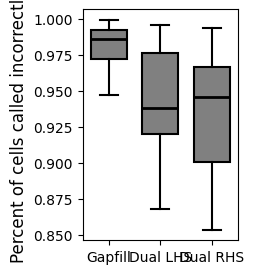

In [4]:
fig, ax = plt.subplots(figsize=(2,3))

data = [
    (merged_accuracies['gapfill']).dropna(),
    (merged_accuracies['dual_lhs']).dropna(),
    (merged_accuracies['dual_rhs']).dropna()
]

ax.boxplot(
    data,
    tick_labels=[
        'Gapfill',
        'Dual LHS',
        'Dual RHS'
    ],
    patch_artist=True,
    boxprops=dict(facecolor='grey', color='k', linewidth=1.5),
    medianprops=dict(color='k', linewidth=2),
    whiskerprops=dict(color='k', linewidth=1.5),
    capprops=dict(color='k', linewidth=1.5),
    showfliers=False,
    widths=0.7  # Make boxes wider
)

ax.set_ylabel('Percent of cells called incorrectly', fontsize=12)
plt.savefig('../plots/dual_vs_gapfill_accuracy_3plex.pdf', bbox_inches='tight')

In [5]:
len(merged_accuracies)

29

In [6]:
## Wilcoxon signed-rank test comparing gapfill and dual LHS
## and get number of shared probes

c1 = 'gapfill'
c2 = 'dual_lhs'

l1 = merged_accuracies.dropna(subset=[c1,c2])[c1]
l2 = merged_accuracies.dropna(subset=[c1,c2])[c2]

st.wilcoxon(l1, l2, alternative='greater')

WilcoxonResult(statistic=84.0, pvalue=0.02471923828125)

In [7]:
## Wilcoxon signed-rank test comparing gapfill and dual RHS
## and get number of shared probes

c1 = 'gapfill'
c2 = 'dual_rhs'

l1 = merged_accuracies.dropna(subset=[c1,c2])[c1]
l2 = merged_accuracies.dropna(subset=[c1,c2])[c2]

st.wilcoxon(l1, l2, alternative='greater')

WilcoxonResult(statistic=120.0, pvalue=3.0517578125e-05)

In [8]:
len(data[0]), len(data[1]), len(data[2])

(29, 14, 15)